# Atención a mano: Q, K, V y la máscara causal

**Facsímil 3 · Arquitecturas y modelos** — capítulos 2 y 3
(el Transformer por dentro; *queries*, *keys*, *values*, máscara causal y *softmax*).

«Atención» es la palabra más repetida y peor entendida de la IA moderna. En este cuaderno deja de ser
un eslogan: la calculas **a mano**, con NumPy, hasta el último número. Vas a ver cómo cada palabra
«mira» a las demás, cómo se reparte ese foco con una *softmax*, y por qué la **máscara causal** impide
que una palabra haga trampas mirando el futuro. Sin librerías mágicas: cuatro multiplicaciones de
matrices. Entender esto es entender el 80% de por qué funciona un Transformer, y por tanto cualquier
LLM.

### Qué vas a aprender
- Qué problema resuelve la atención que las redes anteriores (RNN) resolvían mal.
- Qué son exactamente la *query*, la *key* y el *value*, con una analogía de **búsqueda**.
- Por qué se divide por $\sqrt{d}$ (el detalle que estabiliza todo).
- Qué hace la **máscara causal** y por qué distingue a un modelo que *genera* de uno que *entiende*.
- Qué es la **atención multi-cabeza** y por qué varias miradas ven más que una.

### Cuánto cuesta
Unos 12 minutos. CPU, sin claves.


> **Inteligencia artificial para gente curiosa** · facsímil interactivo
> 
> Web del facsímil: https://www.iaparagentecuriosa.686f6c61.dev/ · Autor: @686f6c61 · Fecha: 2026-06-26 · Versión 1.0
> 
> Este cuaderno acompaña al facsímil: ejecútalo de arriba abajo, lee cada celda de texto
> antes de correr la de código y detente en las salidas. La gracia no es que «salga», sino
> entender *por qué* sale.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(1)

frase = ["El", "gato", "que", "duerme", "ronronea"]
n, d = len(frase), 16          # 5 palabras, 16 dimensiones por vector
# En un modelo real, Q, K, V salen de multiplicar el embedding por matrices APRENDIDAS.
# Aqui los simulamos con matrices aleatorias para ver la mecanica con claridad.
X = np.random.randn(n, d)
Wq, Wk, Wv = (np.random.randn(d, d) for _ in range(3))
Q, K, V = X @ Wq, X @ Wk, X @ Wv
print("Cada palabra es un vector. Formas de Q, K, V:", Q.shape)


Cada palabra es un vector. Formas de Q, K, V: (5, 16)


## 1. El problema que resuelve la atención

Antes de los Transformers, para procesar una frase se usaban redes recurrentes (RNN): leían palabra a
palabra, arrastrando un «resumen» de lo anterior. Tenían dos problemas: eran **lentas** (no se pueden
paralelizar, hay que ir en orden) y se les **olvidaba** lo lejano (la primera palabra apenas influía en
la última, frases largas se difuminaban).

La atención da la vuelta a la idea: en vez de arrastrar un resumen, deja que **cada palabra mire
directamente a todas las demás a la vez** y decida de cuáles fiarse. Es paralelizable (todas las
miradas se calculan de golpe) y no sufre de distancia (la palabra 1 y la 100 se conectan igual de
fácil). Ese cambio es lo que hizo posibles los LLM. Vamos a construir ese «mirar».


## 2. Q, K, V: una búsqueda, palabra por palabra

La mejor analogía es una **búsqueda**. Cada palabra genera tres vectores a partir de su embedding:

- una **query** ($Q$): «esto es lo que ando buscando»;
- una **key** ($K$): «esto es lo que yo ofrezco»;
- un **value** ($V$): «esta es la información que aporto si me eliges».

El parecido entre la *query* de una palabra y la *key* de otra (su producto escalar) mide **cuánto le
interesa** mirarla. Es como teclear una búsqueda (query) y compararla con los títulos de los documentos
(keys) para decidir cuáles leer (values). Calculamos esa tabla de parecidos.


In [2]:
scores = Q @ K.T / np.sqrt(d)
print("Tabla de afinidades (fila = quien pregunta, columna = a quien mira):\n")
print("            " + "  ".join(f"{w:>8}" for w in frase))
for i, w in enumerate(frase):
    print(f"{w:>10}  " + "  ".join(f"{scores[i,j]:>8.2f}" for j in range(n)))


Tabla de afinidades (fila = quien pregunta, columna = a quien mira):

                  El      gato       que    duerme  ronronea
        El      5.53     -6.59     -7.77      3.17      8.77
      gato     -5.19     -6.07      7.20      4.90    -17.70
       que     -1.51      3.77     33.84     -1.41    -38.55
    duerme    -21.73      9.11      5.62    -11.52      3.18
  ronronea     -8.07     -2.01    -28.60      2.86     20.55


## 3. ¿Por qué dividir por $\sqrt{d}$?

Fíjate en ese `/ np.sqrt(d)` de la celda anterior. No es un capricho. El producto escalar de dos
vectores de dimensión $d$ crece, en magnitud, con $d$. Si no lo corrigiéramos, con vectores grandes los
*scores* serían enormes, y la *softmax* (que viene ahora) se saturaría: daría casi todo el peso a una
sola palabra y nada a las demás, con gradientes minúsculos que impedirían aprender. Dividir por
$\sqrt{d}$ mantiene los *scores* en un rango razonable. Es uno de esos detalles pequeños que hacen que
el entrenamiento funcione o no.


## 4. La máscara causal: no mirar el futuro

Cuando un modelo **genera** texto, lo hace palabra a palabra de izquierda a derecha. Al decidir la
palabra 2, no puede mirar la 3, 4, 5: aún no existen. Si las mirara durante el entrenamiento, haría
trampa (vería la respuesta). Lo impedimos poniendo $-\infty$ en la mitad superior de la tabla (el
futuro). Así, al normalizar, esas casillas se vuelven cero: imposible mirar hacia delante.


In [3]:
mascara = np.triu(np.ones((n, n)), k=1).astype(bool)   # triangulo superior = futuro
scores_causal = scores.copy()
scores_causal[mascara] = -np.inf
print("Con el futuro tapado (-inf = prohibido mirar):\n")
print("            " + "  ".join(f"{w:>8}" for w in frase))
for i, w in enumerate(frase):
    fila = "  ".join(("    -inf" if scores_causal[i,j]==-np.inf else f"{scores_causal[i,j]:>8.2f}") for j in range(n))
    print(f"{w:>10}  " + fila)


Con el futuro tapado (-inf = prohibido mirar):

                  El      gato       que    duerme  ronronea
        El      5.53      -inf      -inf      -inf      -inf
      gato     -5.19     -6.07      -inf      -inf      -inf
       que     -1.51      3.77     33.84      -inf      -inf
    duerme    -21.73      9.11      5.62    -11.52      -inf
  ronronea     -8.07     -2.01    -28.60      2.86     20.55


## 5. Softmax: repartir el 100% de la atención

La *softmax* convierte cada fila en porcentajes que suman 1: cuánta atención dedica cada palabra a cada
una de las anteriores (y a sí misma). Para cada fila $i$, $\text{softmax}(s)_j = e^{s_j} / \sum_k
e^{s_k}$. Esto ya es **el mapa de atención**. Lo imprimimos y lo dibujamos.


Reparto de atencion por fila (cada fila suma 1):

                  El      gato       que    duerme  ronronea
        El      1.00      0.00      0.00      0.00      0.00
      gato      0.71      0.29      0.00      0.00      0.00
       que      0.00      0.00      1.00      0.00      0.00
    duerme      0.00      0.97      0.03      0.00      0.00
  ronronea      0.00      0.00      0.00      0.00      1.00


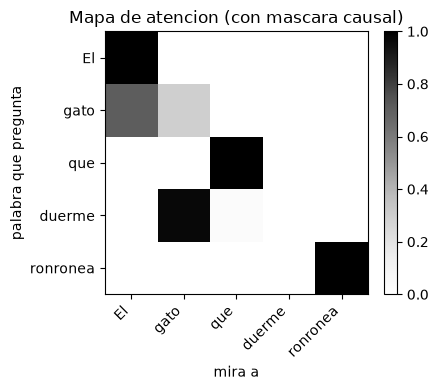

In [4]:
def softmax(x):
    x = x - np.max(x, axis=1, keepdims=True)   # estabilidad numerica
    e = np.exp(x)
    return e / e.sum(axis=1, keepdims=True)

pesos = softmax(scores_causal)
print("Reparto de atencion por fila (cada fila suma 1):\n")
print("            " + "  ".join(f"{w:>8}" for w in frase))
for i, w in enumerate(frase):
    print(f"{w:>10}  " + "  ".join(f"{pesos[i,j]:>8.2f}" for j in range(n)))

plt.figure(figsize=(4.6, 4))
plt.imshow(pesos, cmap="Greys", vmin=0, vmax=1)
plt.xticks(range(n), frase, rotation=45, ha="right"); plt.yticks(range(n), frase)
plt.xlabel("mira a"); plt.ylabel("palabra que pregunta")
plt.title("Mapa de atencion (con mascara causal)")
plt.colorbar(fraction=0.046); plt.tight_layout(); plt.show()


**Lee el mapa.** Es triangular: la mitad de arriba a la derecha está en blanco (cero), porque ninguna
palabra mira a las que vienen después. Cada fila reparte su atención solo entre ella y las anteriores.
Eso es exactamente lo que hace un LLM al generar palabra a palabra. Si quitaras la máscara, el mapa se
llenaría: cada palabra vería a todas, que es la atención *bidireccional* de modelos como BERT, buena
para *entender* (clasificar, extraer) pero no para *generar*.


## 6. Mezclar los valores: la salida de la capa

Por último, cada palabra se queda con una **mezcla de los valores** ($V$) de las palabras que mira,
pesada por su atención: $\text{salida} = \text{pesos} \cdot V$. Ese vector mezclado es lo que sale de la
capa de atención y sigue hacia adelante en el Transformer. En los pesos verás que la primera palabra
solo puede atenderse a sí misma (la máscara le tapa todo lo demás), mientras que las posteriores
reparten su atención entre las palabras que sí pueden ver, según cuánto se parecen sus *queries* y
*keys* (con vectores aleatorios, unas se concentran más y otras menos).


In [5]:
salida = pesos @ V
print("Salida de la capa de atencion:", salida.shape, "\n")
print("Reparto de atencion de cada palabra (los ceros a la derecha son el futuro tapado):")
for i, w in enumerate(frase):
    print(f"  {w:>9}: {np.round(pesos[i], 2)}")
print(f"\nLa primera palabra ('{frase[0]}') solo puede atenderse a si misma (peso {pesos[0,0]:.2f}): la")
print("mascara le tapa todo lo demas. Las siguientes reparten entre lo que SI pueden ver, segun parecido.")


Salida de la capa de atencion: (5, 16) 

Reparto de atencion de cada palabra (los ceros a la derecha son el futuro tapado):
         El: [1. 0. 0. 0. 0.]
       gato: [0.71 0.29 0.   0.   0.  ]
        que: [0. 0. 1. 0. 0.]
     duerme: [0.   0.97 0.03 0.   0.  ]
   ronronea: [0. 0. 0. 0. 1.]

La primera palabra ('El') solo puede atenderse a si misma (peso 1.00): la
mascara le tapa todo lo demas. Las siguientes reparten entre lo que SI pueden ver, segun parecido.


## 7. Varias miradas: atención multi-cabeza

Una sola atención reparte un único foco. Pero una palabra puede querer mirar a otras por **motivos
distintos** a la vez (concordancia de género, sujeto del verbo, referencia de un pronombre...). Por eso
los Transformers usan **varias cabezas** de atención en paralelo, cada una con sus propias matrices
$W_q, W_k, W_v$, y luego combinan sus salidas. Simulamos 3 cabezas y vemos que cada una produce un mapa
de atención **diferente**: miran cosas distintas.


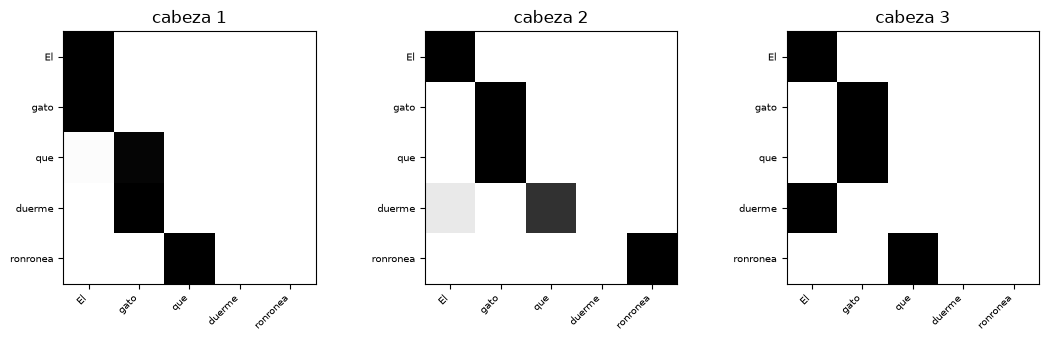

Tres cabezas, tres mapas distintos: cada una aprende a mirar un tipo de relacion.


In [6]:
def una_cabeza(X, d):
    Wq, Wk, Wv = (np.random.randn(d, d) for _ in range(3))
    Q, K, V = X @ Wq, X @ Wk, X @ Wv
    s = Q @ K.T / np.sqrt(d)
    s[np.triu(np.ones((n,n)), k=1).astype(bool)] = -np.inf
    return softmax(s)

fig, axes = plt.subplots(1, 3, figsize=(11, 3.4))
for h, ax in enumerate(axes):
    pesos_h = una_cabeza(X, d)
    ax.imshow(pesos_h, cmap="Greys", vmin=0, vmax=1)
    ax.set_xticks(range(n)); ax.set_xticklabels(frase, rotation=45, ha="right", fontsize=7)
    ax.set_yticks(range(n)); ax.set_yticklabels(frase, fontsize=7)
    ax.set_title(f"cabeza {h+1}")
plt.tight_layout(); plt.show()
print("Tres cabezas, tres mapas distintos: cada una aprende a mirar un tipo de relacion.")


## 8. Pruébalo tú

1. **Quita la máscara** (usa `scores` en vez de `scores_causal` en la celda de la *softmax*). El mapa se
   llena: atención bidireccional. ¿Por qué eso sirve para clasificar pero no para generar?
2. **Sube la dimensión** `d` a 64 y observa el mapa: los repartos cambian, la mecánica no.
3. **Quita el `/np.sqrt(d)`** y mira los pesos: ¿se concentran casi todos en una palabra? Acabas de ver
   por qué el escalado existe.
4. **Compara las cabezas:** ¿se parecen los tres mapas o son muy distintos? Esa diversidad es la razón
   de usar varias.


## 9. Errores comunes

- **Pensar que Q, K, V son cosas mágicas.** Son tres proyecciones lineales del embedding; lo que las
  hace útiles es que sus matrices se *aprenden*.
- **Olvidar el escalado $\sqrt{d}$.** Sin él, la *softmax* se satura y el modelo no aprende bien.
- **Confundir atención causal y bidireccional.** La máscara es lo único que separa un GPT (genera) de un
  BERT (entiende). Misma maquinaria, distinta máscara.
- **Creer que una cabeza basta.** Varias cabezas capturan relaciones distintas; es parte de por qué los
  Transformers son tan expresivos.


## 10. Qué te llevas

- La atención es **un reparto de pesos**: cada palabra decide cuánto mira a cada otra, vía parecido
  *query*-*key*, normalizado con *softmax*, y se lleva una mezcla de los *values*.
- La **máscara causal** es lo que distingue a un modelo que *genera* (solo mira el pasado) de uno que
  *entiende* (mira todo). Una matriz triangular, nada más.
- Detalles como el **escalado** $\sqrt{d}$ y la **multi-cabeza** no son adornos: son lo que hace que el
  mecanismo funcione y sea expresivo.
- Apilando muchas de estas capas se construye un Transformer (capítulo 4: MLP, residual, *logits*).

**Para seguir:** el capítulo 4 termina el bloque (de la atención a los *logits* y el *sampling*); y el
siguiente cuaderno de este facsímil usa esos *logits* para generar texto.


---

### Ficha del cuaderno

- **Obra:** *Inteligencia artificial para gente curiosa* (facsímil interactivo).
- **Web:** https://www.iaparagentecuriosa.686f6c61.dev/
- **Autor:** @686f6c61
- **Fecha:** 2026-06-26
- **Versión:** 1.0

*Material pedagógico. Las salidas que ves son reales: se generan al ejecutar el código, no están escritas a mano. Si cambias algo, cambiarán: esa es la idea.*